# Session 4 — Styling & Colormaps

Runnable code from the **Build It**, **Experiment**, and **Mini Project** sections.
Run each cell top to bottom.

## 1. Build It — Core Code

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

### 4.1 Colors: named, hex, and RGBA

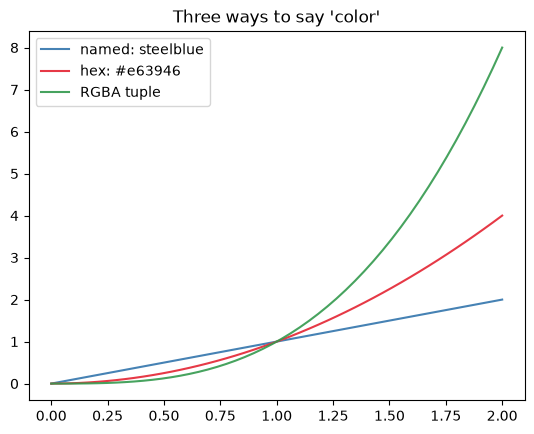

In [2]:
x = np.linspace(0, 2, 50)

fig, ax = plt.subplots()
ax.plot(x, x, color="steelblue", label="named: steelblue")
ax.plot(x, x ** 2, color="#e63946", label="hex: #e63946")
ax.plot(x, x ** 3, color=(0.2, 0.6, 0.3, 0.9), label="RGBA tuple")
ax.set_title("Three ways to say 'color'")
ax.legend()
plt.show()

### 4.2 Transparency with `alpha` reveals density

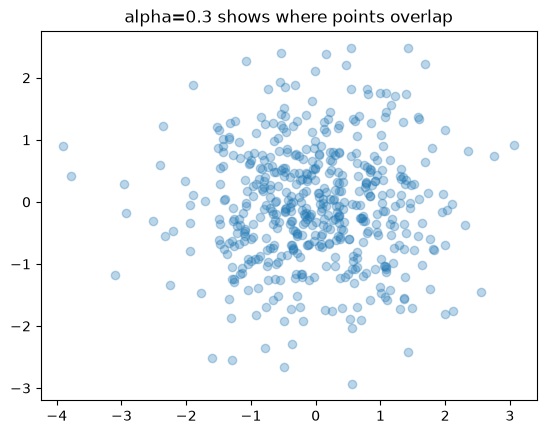

In [3]:
rng = np.random.default_rng(0)
xs, ys = rng.normal(size=500), rng.normal(size=500)

fig, ax = plt.subplots()
ax.scatter(xs, ys, alpha=0.3, color="C0")
ax.set_title("alpha=0.3 shows where points overlap")
plt.show()

### 4.3 Linestyle, marker, and linewidth

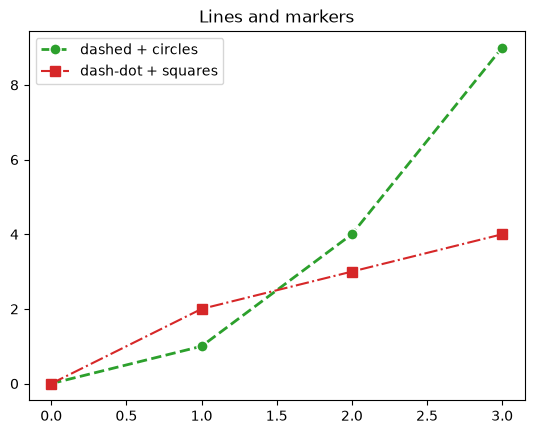

In [4]:
fig, ax = plt.subplots()
ax.plot([0, 1, 2, 3], [0, 1, 4, 9], linestyle="--", marker="o",
        linewidth=2, markersize=8, color="C2",
        markeredgecolor="white", label="dashed + circles")
ax.plot([0, 1, 2, 3], [0, 2, 3, 4], linestyle="-.", marker="s",
        linewidth=1.5, markersize=7, color="C3", label="dash-dot + squares")
ax.set_title("Lines and markers")
ax.legend()
plt.show()

### 4.4 Global defaults with `rcParams`

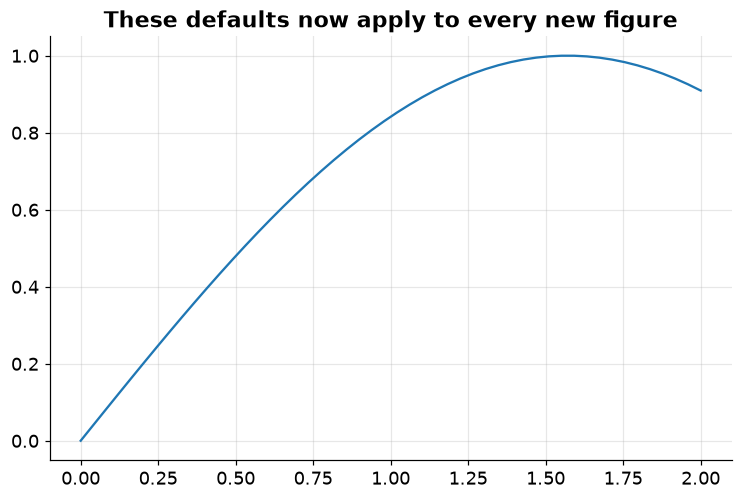

In [5]:
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

fig, ax = plt.subplots()
ax.plot(x, np.sin(x), color="C0")
ax.set_title("These defaults now apply to every new figure")
plt.show()

### 4.5 Built-in style sheets

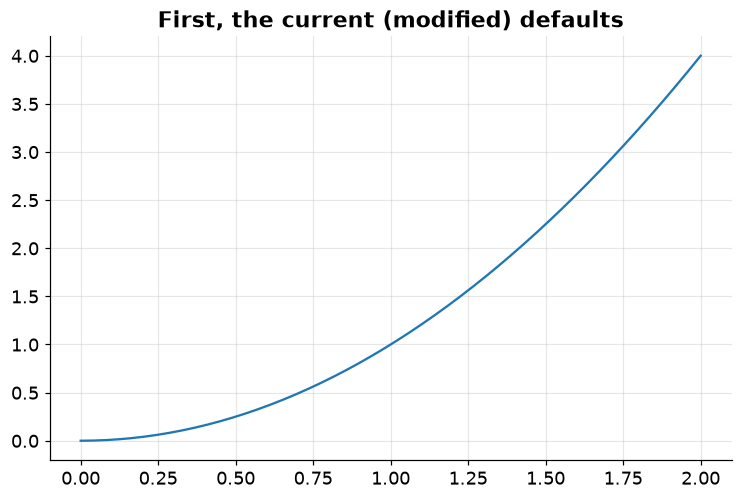

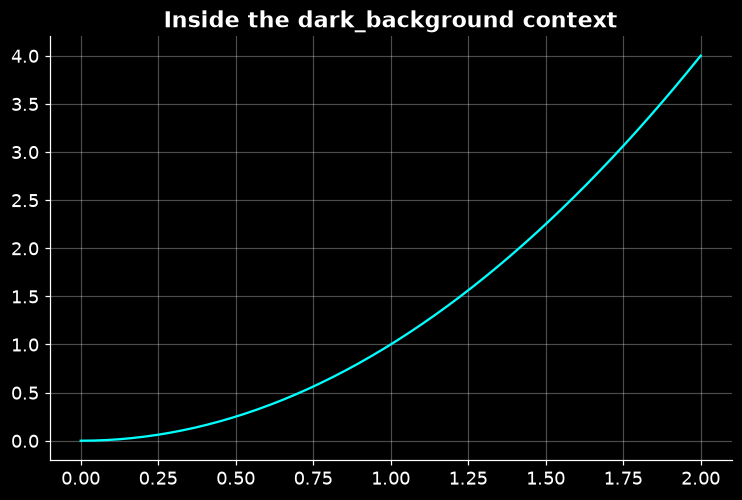

In [6]:
fig, ax = plt.subplots()
ax.plot(x, x ** 2)
ax.set_title("First, the current (modified) defaults")
plt.show()

with plt.style.context("dark_background"):
    fig, ax = plt.subplots()
    ax.plot(x, x ** 2, color="cyan")
    ax.set_title("Inside the dark_background context")
    plt.show()

### 4.6 Colormaps on a scatter plot

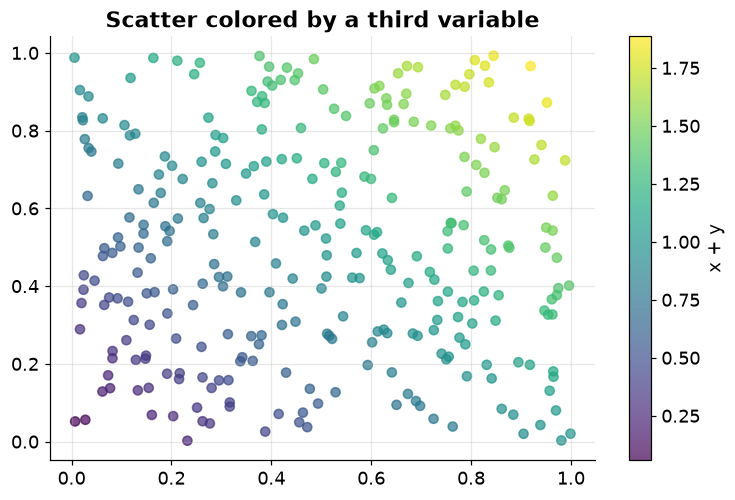

In [7]:
rng = np.random.default_rng(1)
xs = rng.uniform(size=300)
ys = rng.uniform(size=300)
colors = xs + ys

fig, ax = plt.subplots()
sc = ax.scatter(xs, ys, c=colors, cmap="viridis", alpha=0.7)
fig.colorbar(sc, ax=ax, label="x + y")
ax.set_title("Scatter colored by a third variable")
plt.show()

### 4.7 Matrices as images: `imshow` + `colorbar`

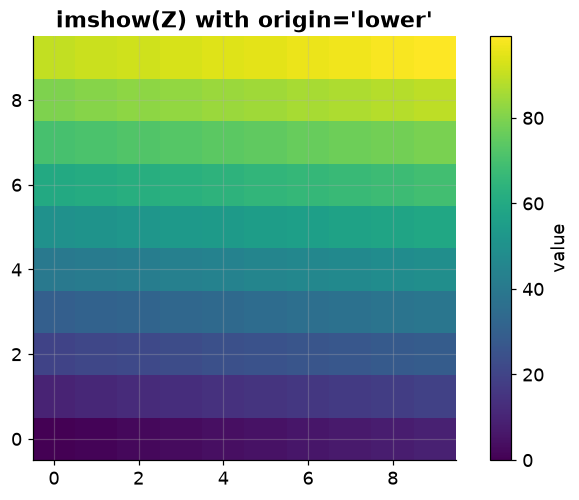

In [8]:
Z = np.arange(100).reshape(10, 10)

fig, ax = plt.subplots()
im = ax.imshow(Z, cmap="viridis", origin="lower")
fig.colorbar(im, ax=ax, label="value")
ax.set_title("imshow(Z) with origin='lower'")
plt.show()

### 4.8 Heatmaps with `pcolormesh`

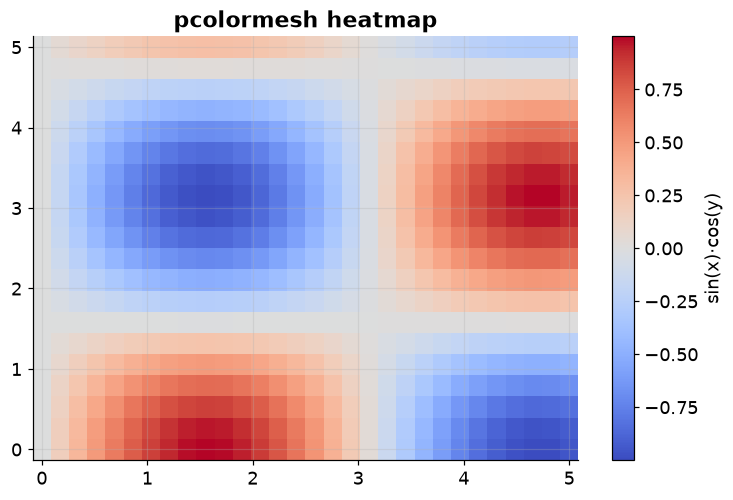

In [9]:
gx = np.linspace(0, 5, 30)
gy = np.linspace(0, 5, 20)
X, Y = np.meshgrid(gx, gy)
H = np.sin(X) * np.cos(Y)

fig, ax = plt.subplots()
mesh = ax.pcolormesh(X, Y, H, cmap="coolwarm", shading="auto")
fig.colorbar(mesh, ax=ax, label="sin(x)·cos(y)")
ax.set_title("pcolormesh heatmap")
plt.show()

## 2. Experiment

Try each experiment and predict the visual result *before* you run it.

#### Experiment 1: the same data under different colormaps

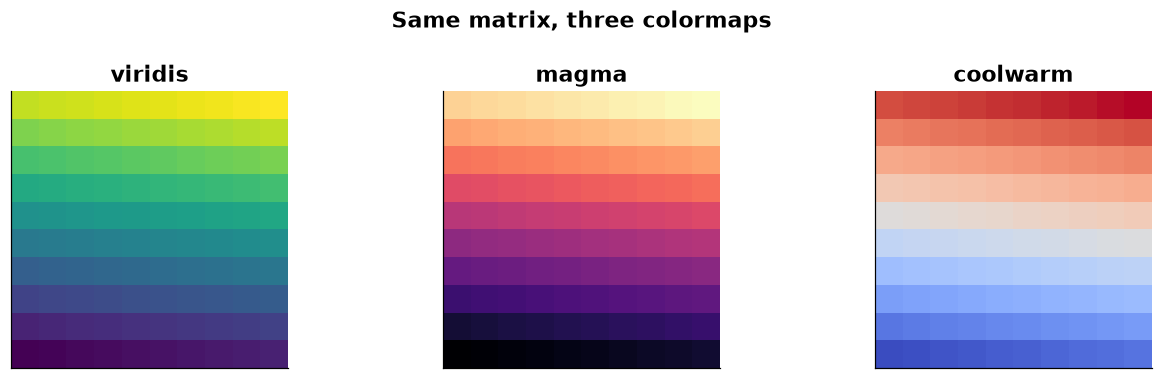

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, cmap in zip(axes, ["viridis", "magma", "coolwarm"]):
    im = ax.imshow(Z, cmap=cmap, origin="lower")
    ax.set_title(cmap)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Same matrix, three colormaps", fontweight="bold")
fig.tight_layout()
plt.show()

#### Experiment 2: markers and line styles change the reading

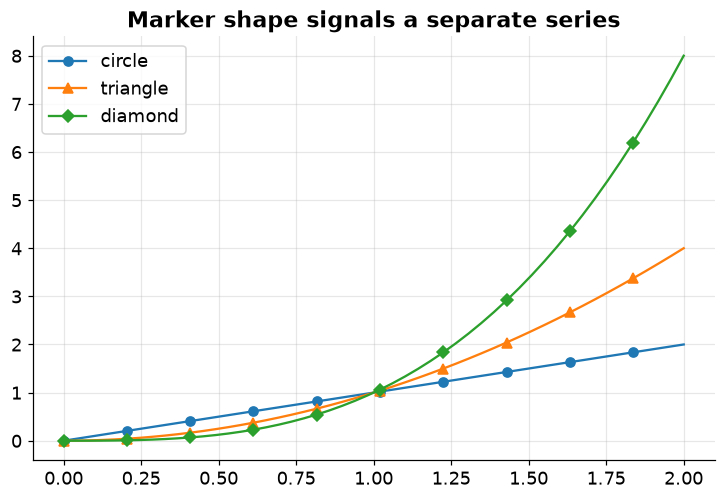

In [11]:
fig, ax = plt.subplots()
ax.plot(x, x, marker="o", markevery=5, label="circle")
ax.plot(x, x ** 2, marker="^", markevery=5, label="triangle")
ax.plot(x, x ** 3, marker="D", markevery=5, label="diamond")
ax.set_title("Marker shape signals a separate series")
ax.legend()
plt.show()

#### Experiment 3: normalize by hand with `vmin` / `vmax`

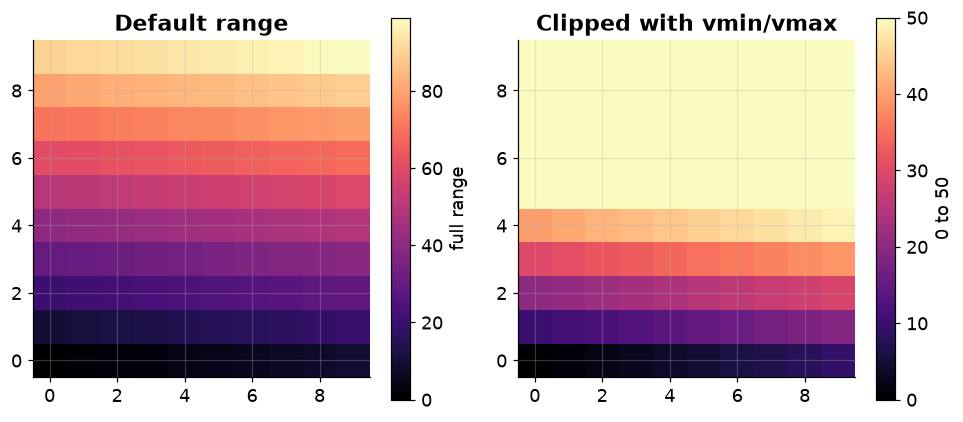

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
im0 = axes[0].imshow(Z, cmap="magma", origin="lower")
fig.colorbar(im0, ax=axes[0], label="full range")
im1 = axes[1].imshow(Z, cmap="magma", origin="lower", vmin=0, vmax=50)
fig.colorbar(im1, ax=axes[1], label="0 to 50")
axes[0].set_title("Default range")
axes[1].set_title("Clipped with vmin/vmax")
fig.tight_layout()
plt.show()

#### Experiment 4: reset the global defaults

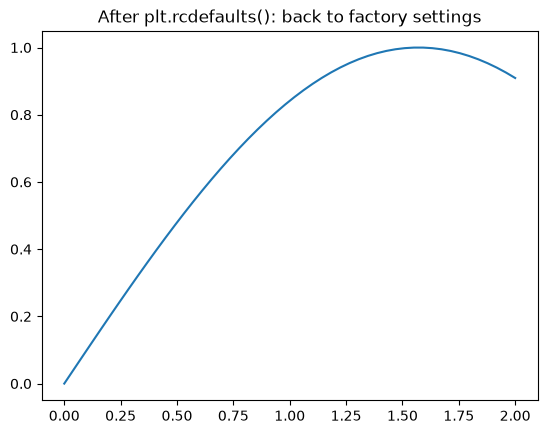

In [13]:
plt.rcdefaults()

fig, ax = plt.subplots()
ax.plot(x, np.sin(x))
ax.set_title("After plt.rcdefaults(): back to factory settings")
plt.show()

## 3. Mini Project — Chart Makeover

Take the same data from a plain default chart to a polished one, then show
them side by side and save a publication-quality PNG.

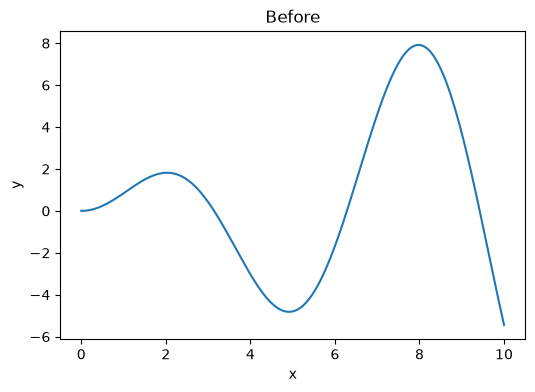

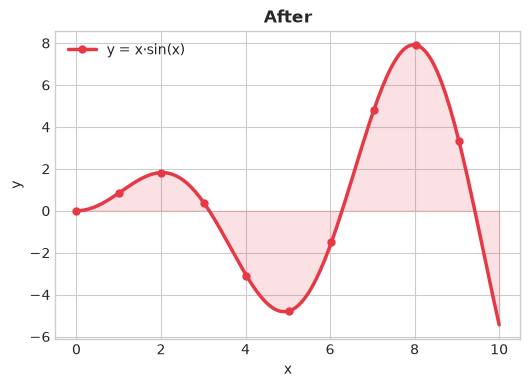

In [14]:
import os

mx = np.linspace(0, 10, 200)
my = np.sin(mx) * mx

# ---- Before: untouched defaults ----
fig_before, ax_before = plt.subplots(figsize=(6, 4))
ax_before.plot(mx, my)
ax_before.set_title("Before")
ax_before.set_xlabel("x")
ax_before.set_ylabel("y")

# ---- After: styled ----
with plt.style.context("seaborn-v0_8-whitegrid"):
    fig_after, ax_after = plt.subplots(figsize=(6, 4))
    ax_after.plot(mx, my, color="#e63946", linewidth=2.5,
                  marker="o", markersize=5, markevery=20,
                  label="y = x·sin(x)")
    ax_after.fill_between(mx, my, alpha=0.15, color="#e63946")
    ax_after.set_title("After", fontweight="bold")
    ax_after.set_xlabel("x")
    ax_after.set_ylabel("y")
    ax_after.legend()

plt.show()

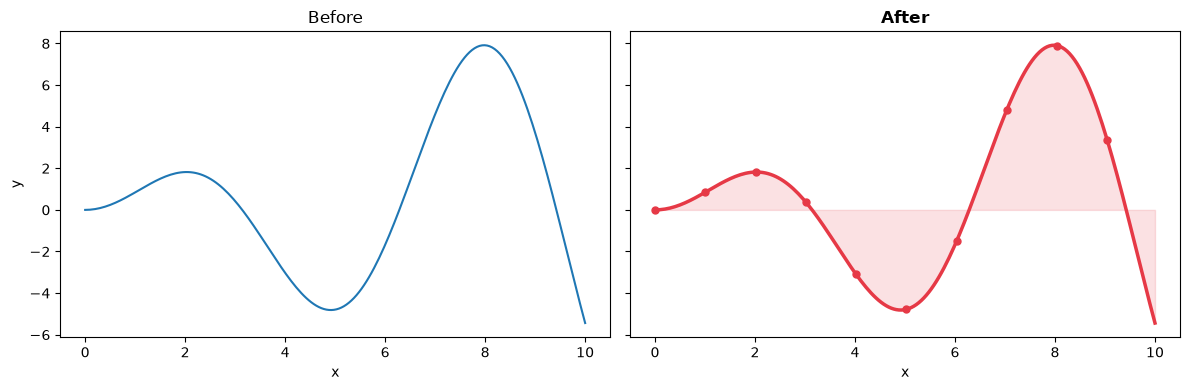

In [15]:
# Compare the two versions side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].plot(mx, my)
axes[0].set_title("Before")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].plot(mx, my, color="#e63946", linewidth=2.5,
             marker="o", markersize=5, markevery=20)
axes[1].fill_between(mx, my, alpha=0.15, color="#e63946")
axes[1].set_title("After", fontweight="bold")
axes[1].set_xlabel("x")
fig.tight_layout()
plt.show()

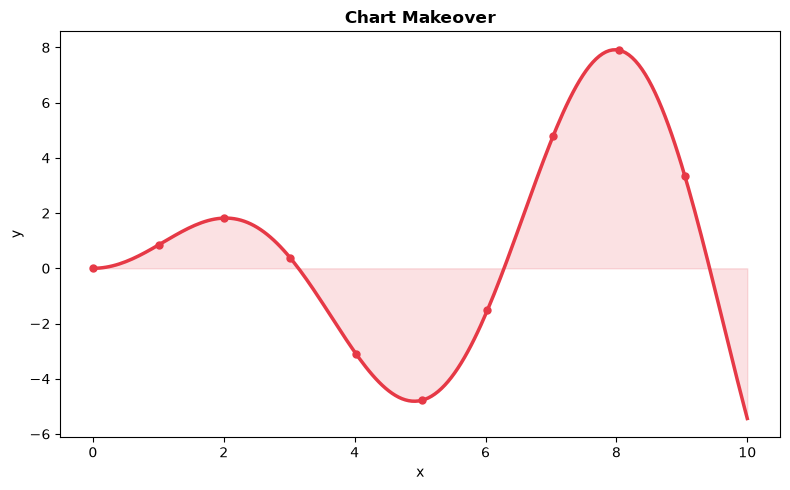

Saved and removed chart_makeover.png


In [16]:
# Save at publication quality, then clean up the file so the folder stays tidy.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mx, my, color="#e63946", linewidth=2.5,
        marker="o", markersize=5, markevery=20)
ax.fill_between(mx, my, alpha=0.15, color="#e63946")
ax.set_title("Chart Makeover", fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.tight_layout()
fig.savefig("chart_makeover.png", dpi=150, bbox_inches="tight")
plt.show()

os.remove("chart_makeover.png")
print("Saved and removed chart_makeover.png")